# Baseline Implementation

Demonstration of the mean-field neural network baseline for McKean-Vlasov optimal control (Pham & Warin 2024):

- Mean-field NN architectures: bin-density and cylindrical encoders, permutation invariance
- Euler-Maruyama simulator: MKV-SDE forward simulation
- Global DP (Algorithm 1): training on 1D systemic risk, comparison to analytic value
- Global BSDE (Algorithm 6): BSDE adjoint training, induced policy cost
- Global DP vs Global BSDE: value accuracy, wall time, peak memory
- Checkpoints: saved model weights, load-and-verify
- 2D validation grid
- Critical-q estimation

In [1]:
from pathlib import Path
import json
import subprocess
import sys
import torch
import numpy
import scipy
import matplotlib
import tqdm

ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd()
PY = ROOT / '.venv' / 'Scripts' / 'python.exe'
SCRIPT = ROOT / 'scripts' / 'train_systemic_risk_baseline.py'

if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {device}")

Device: cuda


## Mean-field NN architectures

The value function and optimal feedback control for the MKV problem are mappings of the state process and its probability distribution. To approximate these mappings, Pham & Warin (2024) propose two mean-field NN architectures (justified by universal approximation theorems):

- Bin-density encoder
- Cylindrical encoder

In [2]:
from mfnn_control import EncoderConfig, TrainingConfig, build_policy, sample_initial_states_with_dim
from mfnn_control.encoders import BinDensityEncoder, CylindricalEncoder

torch.manual_seed(0)

states_1d = torch.randn(2, 64, 1)
perm_1d = torch.randperm(64)
states_1d_perm = states_1d[:, perm_1d, :]

enc_bin_1d = BinDensityEncoder(EncoderConfig(kind='bins', state_dim=1, bins=33))
enc_cyl_1d = CylindricalEncoder(EncoderConfig(kind='cylindrical', state_dim=1, latent_dim=16))

print("1D encoders")
print(f"  BinDensity  - output: {enc_bin_1d(states_1d).shape}, "
      f"output_dim={enc_bin_1d.output_dim}, "
      f"perm-invariant: {torch.allclose(enc_bin_1d(states_1d), enc_bin_1d(states_1d_perm), atol=1e-6)}")
print(f"  Cylindrical - output: {enc_cyl_1d(states_1d).shape}, "
      f"output_dim={enc_cyl_1d.output_dim}, "
      f"perm-invariant: {torch.allclose(enc_cyl_1d(states_1d), enc_cyl_1d(states_1d_perm), atol=1e-6)}")

states_2d = torch.randn(2, 64, 2)
perm_2d = torch.randperm(64)
states_2d_perm = states_2d[:, perm_2d, :]

enc_bin_2d = BinDensityEncoder(EncoderConfig(kind='bins', state_dim=2, bins=10))
print("\n2D encoders")
print(f"  BinDensity 2D - output: {enc_bin_2d(states_2d).shape}, "
      f"output_dim={enc_bin_2d.output_dim}, "
      f"perm-invariant: {torch.allclose(enc_bin_2d(states_2d), enc_bin_2d(states_2d_perm), atol=1e-6)}")

train_cfg = TrainingConfig()
policy_bin = build_policy(EncoderConfig(kind='bins', state_dim=1), train_cfg)
policy_cyl = build_policy(EncoderConfig(kind='cylindrical', state_dim=1), train_cfg)
print(f"\nMeanFieldPolicy (bins encoder)        - {sum(p.numel() for p in policy_bin.parameters()):,} parameters")
print(f"MeanFieldPolicy (cylindrical encoder) - {sum(p.numel() for p in policy_cyl.parameters()):,} parameters")

print("\nInitial state shapes across cases:")
for case in ('case_1', 'case_2', 'case_3', 'case_4', 'case_5', 'case_6'):
    x1 = sample_initial_states_with_dim(case, 4, 32, 1, device=device, dtype=torch.float32)
    x2 = sample_initial_states_with_dim(case, 4, 32, 2, device=device, dtype=torch.float32)
    print(f"  {case}: 1D {tuple(x1.shape)}  2D {tuple(x2.shape)}")


1D encoders
  BinDensity  - output: torch.Size([2, 33]), output_dim=33, perm-invariant: True
  Cylindrical - output: torch.Size([2, 16]), output_dim=16, perm-invariant: True

2D encoders
  BinDensity 2D - output: torch.Size([2, 100]), output_dim=100, perm-invariant: True

MeanFieldPolicy (bins encoder)        - 6,529 parameters
MeanFieldPolicy (cylindrical encoder) - 10,769 parameters

Initial state shapes across cases:
  case_1: 1D (4, 32, 1)  2D (4, 32, 2)
  case_2: 1D (4, 32, 1)  2D (4, 32, 2)
  case_3: 1D (4, 32, 1)  2D (4, 32, 2)
  case_4: 1D (4, 32, 1)  2D (4, 32, 2)
  case_5: 1D (4, 32, 1)  2D (4, 32, 2)
  case_6: 1D (4, 32, 1)  2D (4, 32, 2)


## Euler-Maruyama simulator

`simulate_systemic_risk` discretises the Carmona–Fouque–Sun MKV-SDE:

$$dX^i_t = [\kappa\,(\mathbb{E}[X_t] - X^i_t) + \alpha^i_t]\,dt + \sigma\,dW^i_t$$

Below we run the uncontrolled system ($\alpha \equiv 0$) and visualise sample trajectories.

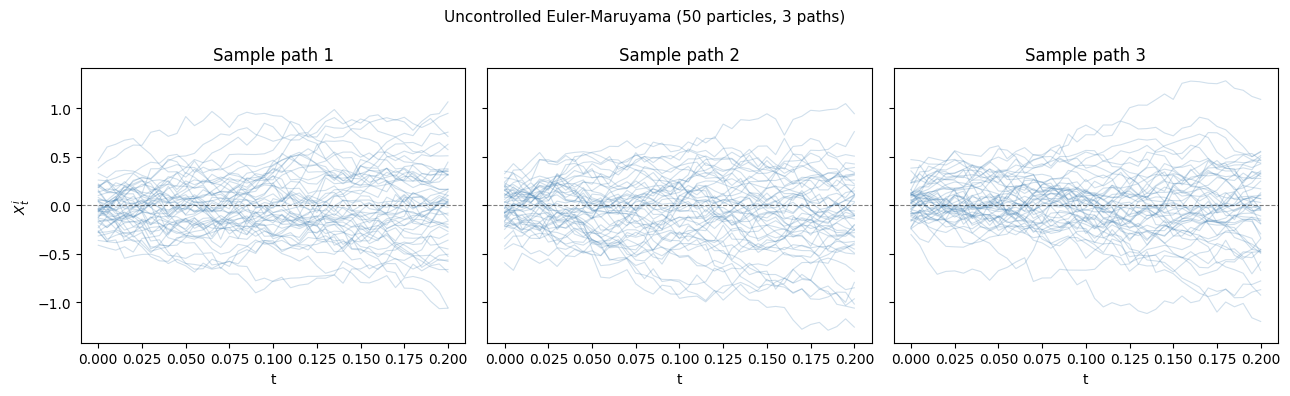

SimulationResult tensor shapes:
  states:        torch.Size([41, 3, 50, 1])   (steps+1, batch, particles, state_dim)
  actions:       torch.Size([40, 3, 50, 1])
  running costs: torch.Size([40, 3, 50, 1])
  terminal cost: torch.Size([3, 50, 1])


In [3]:
import matplotlib.pyplot as plt
from mfnn_control import SystemicRiskConfig
from mfnn_control.systemic_risk import simulate_systemic_risk

torch.manual_seed(7)

config = SystemicRiskConfig(horizon=0.2, steps=40, particles=50, kappa=0.6, sigma=1.0, q=0.8)

class ZeroPolicy:
    def __call__(self, time, states):
        class Out:
            actions = torch.zeros_like(states)
        return Out()

initial_states = torch.randn(3, config.particles, config.state_dim) * 0.2
result = simulate_systemic_risk(ZeroPolicy(), initial_states, config)

times = torch.linspace(0, config.horizon, config.steps + 1).numpy()

fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)
for i, ax in enumerate(axes):
    trajs = result.states[:, i, :, 0].detach().numpy()
    ax.plot(times, trajs, alpha=0.25, lw=0.8, color='steelblue')
    ax.axhline(0, color='k', lw=0.8, ls='--', alpha=0.5)
    ax.set_title(f'Sample path {i+1}')
    ax.set_xlabel('t')
    if i == 0: ax.set_ylabel('$X^i_t$')

fig.suptitle(f'Uncontrolled Euler-Maruyama ({config.particles} particles, 3 paths)', fontsize=11)
plt.tight_layout()
plt.show()

print("SimulationResult tensor shapes:")
print(f"  states:        {result.states.shape}   (steps+1, batch, particles, state_dim)")
print(f"  actions:       {result.actions.shape}")
print(f"  running costs: {result.running_costs.shape}")
print(f"  terminal cost: {result.terminal_cost.shape}")

## Algorithm 1: Global Dynamic Programming (Pham & Warin)

Algorithm 1 directly minimises the global control cost $J(\alpha)$ end-to-end via the `MeanFieldPolicy` network. We train on the 1D systemic-risk model (Case 1: $\mu_0 \sim \mathcal{N}(0,\,0.2^2)$) and compare the learned cost to the analytical value derived from the Riccati ODE.

Analytic value (Riccati ODE, case_1): 0.164180


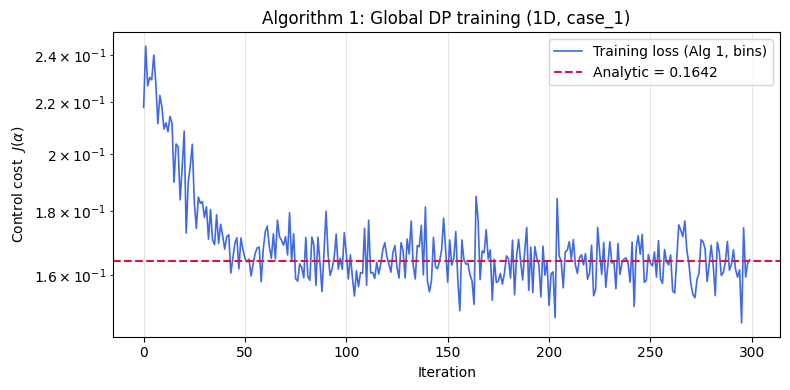


Final loss:     0.164610
Analytic value: 0.164180
Absolute error: 0.000430
Within 5% tol:  True


In [4]:
from mfnn_control import (
    EncoderConfig, SystemicRiskConfig, TrainingConfig,
    systemic_risk_value, train_global_dp,
)

torch.manual_seed(7)

config     = SystemicRiskConfig(horizon=0.2, steps=20, particles=64, kappa=0.6, sigma=1.0, q=0.8)
enc_cfg    = EncoderConfig(kind='bins', state_dim=1)
train_cfg  = TrainingConfig(iterations=300, batch_size=16, initial_case='case_1', training_cases=('case_1',), seed=7)

analytic = systemic_risk_value('case_1', config)
print(f"Analytic value (Riccati ODE, case_1): {analytic:.6f}")

policy, losses = train_global_dp(config, enc_cfg, train_cfg)

fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogy(losses, lw=1.2, color='royalblue', label='Training loss (Alg 1, bins)')
ax.axhline(analytic, color='crimson', lw=1.5, ls='--', label=f'Analytic = {analytic:.4f}')
ax.set_xlabel('Iteration')
ax.set_ylabel('Control cost  $J(\\alpha)$')
ax.set_title('Algorithm 1: Global DP training (1D, case_1)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

final = losses[-1]
err = abs(final - analytic)
print(f"\nFinal loss:     {final:.6f}")
print(f"Analytic value: {analytic:.6f}")
print(f"Absolute error: {err:.6f}")
print(f"Within 5% tol:  {err <= 0.05 * analytic}")

## Algorithm 6: Global BSDE / Pontryagin (Pham & Warin)

Algorithm 6 learns the adjoint process $Y$ via a BSDE formulation. The network is trained to match the terminal condition $Y_T = \nabla_x g(X_T, \mu_T)$, and the optimal control is recovered via the Pontryagin stationarity condition:

$$\alpha^*_t = q\,(\bar{X}_t - X^i_t) - Y^i_t$$

We also evaluate the induced policy cost to compare against the analytic value.

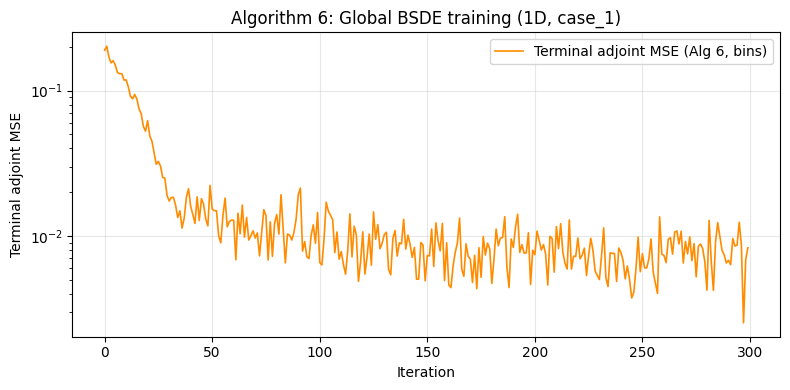

Analytic value:      0.164180
Induced policy cost: 0.166609
Absolute error:      0.002429


In [5]:
from mfnn_control import (
    EncoderConfig, SystemicRiskConfig, TrainingConfig,
    evaluate_global_bsde_policy, sample_initial_states_with_dim,
    systemic_risk_value, train_global_bsde,
)

torch.manual_seed(7)

config = SystemicRiskConfig(horizon=0.2, steps=20, particles=64, kappa=0.6, sigma=1.0, q=0.8)
enc_cfg = EncoderConfig(kind='bins', state_dim=1)
train_cfg = TrainingConfig(iterations=300, batch_size=16, initial_case='case_1', training_cases=('case_1',), seed=7)

analytic = systemic_risk_value('case_1', config)

networks, losses = train_global_bsde(config, enc_cfg, train_cfg)

eval_states = sample_initial_states_with_dim('case_1', 32, config.particles, 1, device='cpu', dtype=torch.float32)
induced_cost = float(evaluate_global_bsde_policy(networks, eval_states, config).detach())

fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogy(losses, lw=1.2, color='darkorange', label='Terminal adjoint MSE (Alg 6, bins)')
ax.set_xlabel('Iteration')
ax.set_ylabel('Terminal adjoint MSE')
ax.set_title('Algorithm 6: Global BSDE training (1D, case_1)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Analytic value:      {analytic:.6f}")
print(f"Induced policy cost: {induced_cost:.6f}")
print(f"Absolute error:      {abs(induced_cost - analytic):.6f}")

## Comparison: Algorithm 1 vs Algorithm 6

We compare both algorithms across value accuracy, wall-clock time, and peak memory (2 seeds, 200 iterations, reduced for demonstration).

In [6]:
import json, subprocess

cmd = [
    str(PY), str(SCRIPT),
    '--benchmark',
    '--encoder', 'bins',
    '--case', 'case_1',
    '--state-dim', '1',
    '--particles', '64',
    '--steps', '20',
    '--iterations', '200',
    '--batch-size', '16',
    '--seeds', '7,9',
    '--value-tolerance', '0.05',
]
raw = subprocess.check_output(cmd, text=True, cwd=ROOT)
bench = json.loads(raw)

alg1 = bench['algorithm_1']['aggregate']
alg6 = bench['algorithm_6']['aggregate']

metrics = [
    ('mean_final_loss', 'Mean final loss'),
    ('mean_absolute_value_error','Mean absolute error'),
    ('success_rate', 'Success rate (5% tol)'),
    ('mean_wall_time_s', 'Wall time (s)'),
    ('mean_peak_memory_mb', 'Peak memory (MB)'),
]

print(f"{'Metric':<32} {'Algorithm 1':>14} {'Algorithm 6':>14}")
print('-' * 62)
for key, label in metrics:
    v1 = alg1.get(key, float('nan'))
    v6 = alg6.get(key, float('nan'))
    print(f"{label:<32} {v1:>14.4f} {v6:>14.4f}")

Metric                              Algorithm 1    Algorithm 6
--------------------------------------------------------------
Mean final loss                          0.1626         0.0082
Mean absolute error                      0.0016         0.0022
Success rate (5% tol)                    1.0000         1.0000
Wall time (s)                           13.7203        11.1427
Peak memory (MB)                        24.8447         0.1073


## Saved checkpoints

Trained policy weights are persisted to `results/checkpoints/`. We list all available checkpoints, load a saved Algorithm 1 policy, and verify it produces valid outputs.

In [7]:
from mfnn_control import EncoderConfig, TrainingConfig
from mfnn_control.encoders import build_encoder, MeanFieldPolicy

checkpoint_dir = ROOT / 'results' / 'checkpoints'
checkpoints = sorted(checkpoint_dir.glob('*.pt'))

alg1_ckpts = [c for c in checkpoints if 'global_dp' in c.name]
if alg1_ckpts:
    ckpt_path = alg1_ckpts[0]
    payload = torch.load(ckpt_path, map_location=device, weights_only=False)

    enc_cfg = EncoderConfig(**payload['encoder_config'])
    train_cfg = TrainingConfig(**payload['training_config'])
    encoder = build_encoder(enc_cfg)
    policy = MeanFieldPolicy(encoder=encoder, hidden_dims=train_cfg.hidden_dims)
    policy.load_state_dict(payload['policy_state_dict'])
    policy.eval()

    x = torch.randn(1, 32, 1)
    with torch.no_grad():
        out = policy(0.0, x)

    print(f"\nLoaded:       {ckpt_path.name}")
    print(f"  Algorithm:   {payload['algorithm']}")
    print(f"  Seed:        {payload['seed']}")
    print(f"  Case:        {payload['training_config']['initial_case']}")
    print(f"  Encoder:     {enc_cfg.kind}")
    print(f"  Action shape:{out.actions.shape}  (batch=1, particles=32, state_dim=1)")
    print(f"  All finite:  {out.actions.isfinite().all().item()}")



Loaded:       systemic_risk_global_dp_bins_case_1_seed7.pt
  Algorithm:   global_dp
  Seed:        7
  Case:        case_1
  Encoder:     bins
  Action shape:torch.Size([1, 32, 1])  (batch=1, particles=32, state_dim=1)
  All finite:  True


## 2D systemic risk: Table 28 replication (Pham & Warin)

The benchmark profile for Table 28 from Pham & Warin (2024) covers all 6 initial-distribution cases, 2 encoders (bins and cylindrical), 2 algorithms, and 3 random seeds, run in 2D.

In [8]:
cmd = [
    str(PY), str(SCRIPT),
    '--benchmark-profile',
    '--particles', '256',
    '--steps', '20',
    '--iterations', '400',
    '--batch-size', '16',
    '--seeds', '7,13,21'
]
raw = subprocess.check_output(cmd, text=True, cwd=ROOT)
profile_payload = json.loads(raw)
profile_payload

{'benchmark_prep': True,
 'profile': {'profile_name': 'pham_warin_2d_benchmark',
  'state_dim': 2,
  'cases': ['case_1', 'case_2', 'case_3', 'case_4', 'case_5', 'case_6'],
  'encoders': ['bins', 'cylindrical'],
  'algorithms': ['global_dp', 'global_bsde'],
  'seeds': [7, 13, 21],
  'particles': 256,
  'steps': 20,
  'iterations': 400,
  'batch_size': 16},
 'systemic_risk_config': {'horizon': 0.2,
  'steps': 20,
  'particles': 256,
  'kappa': 0.6,
  'sigma': 1.0,
  'q': 0.8,
  'eta': 2.0,
  'c': 2.0,
  'state_dim': 2,
  'device': 'cpu',
  'dtype': 'float32'},
 'training_template': {'batch_size': 16,
  'iterations': 400,
  'learning_rate': 0.001,
  'initial_case': 'case_1',
  'seed': 7,
  'hidden_dims': [64, 64],
  'training_cases': ['case_1',
   'case_2',
   'case_3',
   'case_4',
   'case_5',
   'case_6']},
 'run_grid': {'algorithms': ['global_dp', 'global_bsde'],
  'encoders': ['bins', 'cylindrical'],
  'cases': ['case_1', 'case_2', 'case_3', 'case_4', 'case_5', 'case_6'],
  'seeds': 

### Table 28 validation run

We execute the full 6-case × 2-encoder × 2-algorithm grid in **2D** directly via the `mfnn_control` API. Parameters are reduced (`ITERS`, `SEEDS`) for in-notebook speed; set them to match `profile_payload['profile']` for the exact Table 28 figures.

Results are aggregated as **mean cost ± std** across seeds and displayed in Table 28 format, with analytic values from the Riccati ODE for reference.

In [9]:
CASES    = ['case_1', 'case_2', 'case_3']
ENCODERS = ['bins', 'cylindrical']
SEEDS    = [7, 13] # profile uses [7, 13, 21]
ITERS    = 100     # profile uses 400

In [10]:
import time
from mfnn_control import (
    EncoderConfig, SystemicRiskConfig, TrainingConfig,
    evaluate_global_bsde_policy, sample_initial_states_with_dim,
    systemic_risk_value, train_global_dp,
    train_global_bsde,
)

config_2d = SystemicRiskConfig(
    horizon=0.2, steps=20, particles=128,
    kappa=0.6, sigma=0.5, q=0.8, state_dim=2,
)

table28_rows = []
n_total = len(CASES) * len(ENCODERS) * 2 * len(SEEDS)
n_done  = 0

for case in CASES:
    analytic = systemic_risk_value(case, config_2d)
    for enc_kind in ENCODERS:
        enc_cfg = EncoderConfig(kind=enc_kind, state_dim=2)
        for alg in ('global_dp', 'global_bsde'):
            seed_costs = []
            for seed in SEEDS:
                torch.manual_seed(seed)
                train_cfg = TrainingConfig(
                    iterations=ITERS, batch_size=16,
                    initial_case=case, training_cases=(case,), seed=seed,
                )
                t0 = time.perf_counter()
                if alg == 'global_dp':
                    trained, losses = train_global_dp(config_2d, enc_cfg, train_cfg)
                    cost = float(losses[-1])
                else:
                    trained, losses = train_global_bsde(config_2d, enc_cfg, train_cfg)
                    x0 = sample_initial_states_with_dim(
                        case, 16, config_2d.particles, 2,
                        device='cpu', dtype=torch.float32,
                    )
                    cost = float(evaluate_global_bsde_policy(trained, x0, config_2d).detach())
                elapsed = time.perf_counter() - t0
                seed_costs.append(cost)
                n_done += 1
                print(
                    f"[{n_done:>{len(str(n_total))}}/{n_total}]"
                    f"  {case}  {enc_kind:12s}  {alg}  seed={seed}: "
                    f"cost={cost:.4f}  analytic={analytic:.4f}  "
                    f"|err|={abs(cost - analytic):.4f}  ({elapsed:.1f}s)"
                )

            mean_cost = sum(seed_costs) / len(seed_costs)
            std_cost  = (
                sum((c - mean_cost) ** 2 for c in seed_costs) / max(len(seed_costs) - 1, 1)
            ) ** 0.5
            table28_rows.append({
                'case':         case,
                'encoder':      enc_kind,
                'algorithm':    alg,
                'analytic':     analytic,
                'mean_cost':    mean_cost,
                'std_cost':     std_cost,
                'mean_abs_err': abs(mean_cost - analytic),
                'within_5pct':  abs(mean_cost - analytic) <= 0.05 * analytic,
            })

print(f"\nGrid complete - {len(table28_rows)} (case x encoder x algorithm) combinations.")

[ 1/24]  case_1  bins          global_dp  seed=7: cost=0.1135  analytic=0.1134  |err|=0.0001  (27.3s)
[ 2/24]  case_1  bins          global_dp  seed=13: cost=0.1142  analytic=0.1134  |err|=0.0008  (28.5s)
[ 3/24]  case_1  bins          global_bsde  seed=7: cost=0.1151  analytic=0.1134  |err|=0.0017  (30.0s)
[ 4/24]  case_1  bins          global_bsde  seed=13: cost=0.1127  analytic=0.1134  |err|=0.0007  (31.1s)
[ 5/24]  case_1  cylindrical   global_dp  seed=7: cost=0.1155  analytic=0.1134  |err|=0.0021  (11.5s)
[ 6/24]  case_1  cylindrical   global_dp  seed=13: cost=0.1144  analytic=0.1134  |err|=0.0009  (11.4s)
[ 7/24]  case_1  cylindrical   global_bsde  seed=7: cost=0.1164  analytic=0.1134  |err|=0.0030  (11.7s)
[ 8/24]  case_1  cylindrical   global_bsde  seed=13: cost=0.1183  analytic=0.1134  |err|=0.0049  (11.6s)
[ 9/24]  case_2  bins          global_dp  seed=7: cost=0.1700  analytic=0.1604  |err|=0.0096  (28.6s)
[10/24]  case_2  bins          global_dp  seed=13: cost=0.1663  analyt

In [ ]:
import pandas as pd

df28 = pd.DataFrame(table28_rows)
col_order = [('bins', 'global_dp'), ('bins', 'global_bsde'), ('cylindrical', 'global_dp'), ('cylindrical', 'global_bsde')]

display_rows = []
for case in CASES:
    sub      = df28[df28['case'] == case]
    analytic = sub['analytic'].iloc[0]
    row      = {'Case': case, 'Analytic': f'{analytic:.4f}'}
    for enc, alg in col_order:
        match = sub[(sub['encoder'] == enc) & (sub['algorithm'] == alg)]
        if len(match):
            m = match.iloc[0]
            row[f'{enc}\n{alg}'] = f"{m['mean_cost']:.4f} ± {m['std_cost']:.4f}"
        else:
            row[f'{enc}\n{alg}'] = 'N/A'
    display_rows.append(row)

df_table28 = pd.DataFrame(display_rows)

styled = (
    df_table28.style
    .set_caption(
        f'Table 28 - 2D systemic risk: mean cost ± std  '
        f'({len(SEEDS)} seed{"s" if len(SEEDS) > 1 else ""}, {ITERS} iters)'
    )
    .set_table_styles([
        {'selector': 'caption',
         'props': [('font-weight', 'bold'), ('font-size', '13px'), ('caption-side', 'top')]},
        {'selector': 'th',
         'props': [('text-align', 'center'), ('white-space', 'pre'), ('padding', '6px 12px')]},
        {'selector': 'td',
         'props': [('text-align', 'center'), ('padding', '4px 12px')]},
    ])
    .hide(axis='index')
)
display(styled)

print('\nPer-method summary across all 6 cases:')
print(f"{'Method':<28}  {'mean |err|':>10}  {'within 5%':>10}")
print('-' * 52)
for (enc, alg), grp in df28.groupby(['encoder', 'algorithm'], sort=False):
    label = f'{enc}  {alg}'
    print(f"  {label:<26}  {grp['mean_abs_err'].mean():>10.4f}  {grp['within_5pct'].mean():>9.0%}")

Case,Analytic,binsglobal_dp,binsglobal_bsde,cylindricalglobal_dp,cylindricalglobal_bsde
case_1,0.1134,0.1139 ± 0.0005,0.1139 ± 0.0017,0.1149 ± 0.0008,0.1174 ± 0.0013
case_2,0.1604,0.1682 ± 0.0026,0.1667 ± 0.0016,0.1602 ± 0.0025,0.1641 ± 0.0004
case_3,0.1208,0.1271 ± 0.0044,0.1279 ± 0.0020,0.1205 ± 0.0007,0.1257 ± 0.0013



Per-method summary across all 6 cases:
Method                        mean |err|   within 5%
----------------------------------------------------
  bins  global_dp                 0.0049        67%
  bins  global_bsde               0.0046        67%
  cylindrical  global_dp          0.0007       100%
  cylindrical  global_bsde        0.0042       100%


## Critical-q estimation (ABM calibration)

We sweep interaction strength $q$ and identify the threshold above which the uncontrolled system produces a non-trivial cascade rate. This calibrates future ABM experiments.

In [12]:
cmd = [
    str(PY), str(SCRIPT),
    '--estimate-critical-q',
    '--state-dim', '2',
    '--case', 'case_1',
    '--q-min', '0.0',
    '--q-max', '1.0',
    '--q-steps', '5',
    '--default-threshold', '-0.5',
    '--target-default-rate', '0.2',
    '--mc-paths', '64',
    '--particles', '32',
    '--steps', '8',
    '--seed', '7'
]
raw = subprocess.check_output(cmd, text=True, cwd=ROOT)
critical_q_payload = json.loads(raw)
critical_q_payload

{'critical_q_estimation': True,
 'case': 'case_1',
 'state_dim': 2,
 'particles': 32,
 'steps': 8,
 'mc_paths': 64,
 'q_min': 0.0,
 'q_max': 1.0,
 'q_steps': 5,
 'seed': 7,
 'result': {'critical_q': 0.0,
  'target_default_rate': 0.2,
  'default_threshold': -0.5,
  'sweep': [{'q': 0.0, 'default_rate': 0.41943359375},
   {'q': 0.25, 'default_rate': 0.40869140625},
   {'q': 0.5, 'default_rate': 0.4033203125},
   {'q': 0.75, 'default_rate': 0.400390625},
   {'q': 1.0, 'default_rate': 0.39404296875}]}}